# 1. PREPARATION

## 1.1. Read CSV

In [1]:
import pandas as pd


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)


df_old = pd.read_csv('data/dataset.old.csv')
display(df_old.head(3))

,order,year,country,study_focus,historical_site_type,historical_site_type_sub,platform,device,technique,technique_sub,software_data,software_modeling,software_render
0,1,2015,South Korea,Visualization,Building,Religious,VR,HMD,3D Scanning;Modeling & Reconstruction,Laser Scanning;3D Modeling,Australis Photometric,Autodesk 3ds Max,Unity
1,2,2015,Spain,Reconstruction,Archaeological Site,LandBased,AR,Mobile,Image-Based Techniques;Modeling & Reconstruction,Photogrammetry;Structure from Motion (SfM);3D Modeling,Agisoft Metashape,Blender,NaN
2,3,2015,Peru,Visualization,Archaeological Site,LandBased,AR,Mobile,Image-Based Techniques,Photogrammetry;Structure from Motion (SfM),Agisoft Metashape,NaN,NaN


## 1.2. Tokenize Dataset

In [3]:
def get_multi_value_columns(df):
    multi_value_columns = []
    
    for col in df.columns:
        if df[col].dropna().astype(str).str.contains(";").any():
            multi_value_columns.append(col)
            
    return multi_value_columns


multi_value_columns = get_multi_value_columns(df_old)
print(*multi_value_columns, sep="\n")

platform
device
technique
technique_sub
software_data
software_modeling
software_render


In [4]:
def tokenize_columns(df, columns_to_tokenize):
    for col in columns_to_tokenize:
        df[col] = df[col].fillna("").apply(
            lambda x: [item.strip() for item in str(x).split(";") if item.strip()]
        )
        
    return df


df_old_tokenized = tokenize_columns(df_old, multi_value_columns)
display(df_old_tokenized.tail(3))

,order,year,country,study_focus,historical_site_type,historical_site_type_sub,platform,device,technique,technique_sub,software_data,software_modeling,software_render
89,90,2024,Cyprus,Visualization,Archaeological Site,Underwater,[VR],[HMD],"[Image-Based Techniques, Geospatial Techniques]","[Photogrammetry, Structure from Motion (SfM), Geographic Information System (GIS)]",[Agisoft Metashape],[Blender],[Unreal Engine]
90,91,2024,Jordan,Reconstruction,Archaeological Site,LandBased,[VR],[HMD],[Image-Based Techniques],[Photogrammetry],[Agisoft Metashape],[],[Unreal Engine]
91,92,2024,Italy,Visualization,Natural Space,Cave,[VR],[HMD],[Image-Based Techniques],[Photogrammetry],[Reality Capture],[],[Unreal Engine]


## 1.3. Add ÉLŐ Scores

In [7]:
ELOS_OLD = [
    1691, 1572, 1531, 1466, 1728, 1505, 1294, 1357, 1227, 1448, 
    1382, 1248, 1458, 1654, 1432, 1279, 1441, 1670, 1281, 1567, 
    1330, 1418, 1799, 1414, 1407, 1550, 1363, 1592, 1343, 1346, 
    1436, 1637, 1568, 1552, 1441, 1612, 1489, 1443, 1529, 1540, 
    1646, 1447, 1631, 1210, 1557, 1447, 1415, 1416, 1551, 1211, 
    1610, 1716, 1526, 1364, 1273, 1738, 1488, 1402, 1591, 1680, 
    1466, 1263, 1582, 1616, 1493, 1526, 1505, 1495, 1259, 1505, 
    1663, 1750, 1669, 1591, 1505, 1468, 1402, 1500, 1477, 1487, 
    1611, 1707, 1438, 1687, 1563, 1646, 1411, 1655, 1545, 1421, 
    1638, 1479
]


df_old_tokenized['elo'] = ELOS_OLD
df_old_elos_added = df_old
display(df_old_elos_added.tail(3))

,order,year,country,study_focus,historical_site_type,historical_site_type_sub,platform,device,technique,technique_sub,software_data,software_modeling,software_render,elo
89,90,2024,Cyprus,Visualization,Archaeological Site,Underwater,[VR],[HMD],"[Image-Based Techniques, Geospatial Techniques]","[Photogrammetry, Structure from Motion (SfM), Geographic Information System (GIS)]",[Agisoft Metashape],[Blender],[Unreal Engine],1421
90,91,2024,Jordan,Reconstruction,Archaeological Site,LandBased,[VR],[HMD],[Image-Based Techniques],[Photogrammetry],[Agisoft Metashape],[],[Unreal Engine],1638
91,92,2024,Italy,Visualization,Natural Space,Cave,[VR],[HMD],[Image-Based Techniques],[Photogrammetry],[Reality Capture],[],[Unreal Engine],1479


## 1.4. Summary

In [8]:
def get_column_statistics(df, column_name, is_list):
    total_rows = len(df)
    stats = []
    
    if is_list:
        all_items = []
        for lst in df[column_name].dropna():
            if isinstance(lst, list):
                all_items.extend(lst)
        unique_labels = sorted(list(set(all_items)))
    else:
        unique_labels = sorted(df[column_name].dropna().unique().tolist())
        
    for label in unique_labels:
        if is_list:
            count = df[column_name].apply(lambda x: label in x if isinstance(x, list) else False).sum()
        else:
            count = (df[column_name] == label).sum()
            
        percent = round((count / total_rows) * 100, 1)
        stats.append((label, count, percent))
        
    return stats


def print_formatted_table(column_name, stats, w_name, w_count, w_pct):
    print("\n")
    print(f"{column_name:<{w_name}} | {'count':<{w_count}} | {'percent':<{w_pct}}")
    print("─" * 70)

    for label, count, percent in stats:
        percent_str = f"{percent}%"
        print(f"{str(label):<{w_name}} | {str(count):<{w_count}} | {percent_str:<{w_pct}}")


def print_dataset_summary(df, multi_value_columns, w_name=40, w_count=10, w_pct=10):
    ignore_columns = ['order', 'year', 'country', 'elo']
        
    for col in df.columns:
        if col in ignore_columns:
            continue
            
        is_list = col in multi_value_columns
        stats = get_column_statistics(df, col, is_list)
        print_formatted_table(col, stats, w_name, w_count, w_pct)


print_dataset_summary(df_old_elos_added, multi_value_columns)



study_focus                              | count      | percent   
──────────────────────────────────────────────────────────────────────
Reconstruction                           | 27         | 29.3%     
Restoration                              | 7          | 7.6%      
Visualization                            | 58         | 63.0%     


historical_site_type                     | count      | percent   
──────────────────────────────────────────────────────────────────────
Archaeological Site                      | 47         | 51.1%     
Artistic Feature                         | 6          | 6.5%      
Building                                 | 33         | 35.9%     
Natural Space                            | 6          | 6.5%      


historical_site_type_sub                 | count      | percent   
──────────────────────────────────────────────────────────────────────
ArchitecturalAsset                       | 2          | 2.2%      
Artifact                                 | 4

# 2. K-MEAN

## 2.1. Elbow Method

Calculated K_MAX: 7 (for N=92)

k (Clusters) | Inertia
------------------------------
1            | 1,669,296.48
2            | 571,533.55
3            | 255,897.58
4            | 141,624.88
5            | 96,025.36
6            | 69,311.96


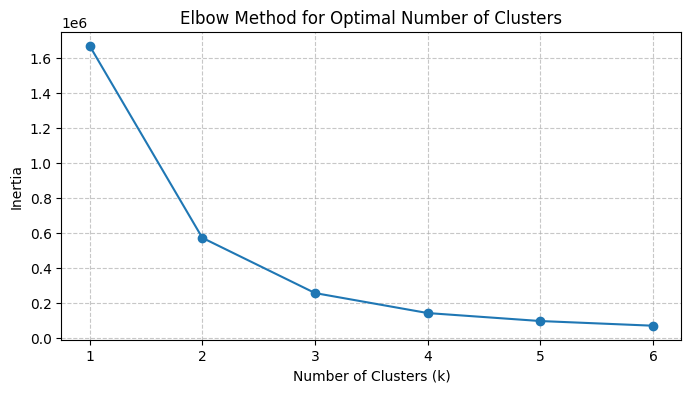

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


def plot_elbow_method(elos, k_max, random_state):
    X = np.array(elos).reshape(-1, 1)
    k_values = list(range(1, k_max))
    
    inertias = []
    for k in k_values:
        k_mean = KMeans(n_clusters=k, random_state=random_state).fit(X)
        inertias.append(k_mean.inertia_)

    print(f"\n{'k (Clusters)':<12} | {'Inertia'}")
    print("-" * 30)
    for k, val in zip(k_values, inertias):
        print(f"{k:<12} | {val:,.2f}")

    plt.figure(figsize=(8, 4))
    plt.plot(k_values, inertias, marker="o")
    plt.xticks(k_values)
    plt.title("Elbow Method for Optimal Number of Clusters")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia")
    plt.grid(True, linestyle='--', alpha=0.7)
    
    return plt


N     = len(ELOS)
K_MAX = int(round(np.sqrt(N / 2)))
print(f"Calculated K_MAX: {K_MAX} (for N={N})")

RANDOM_STATE = 42
PATH_PLOT    = 'data/K_MEAN_OLD.png'

plt = plot_elbow_method(ELOS_OLD, K_MAX, RANDOM_STATE)
plt.savefig(PATH_PLOT)
plt.show()

## 2.2. Davies-Bouldin Method


k (Clusters) | Score
------------------------------
2            | 0.58650
3            | 0.50079
4            | 0.49071
5            | 0.49554
6            | 0.48036


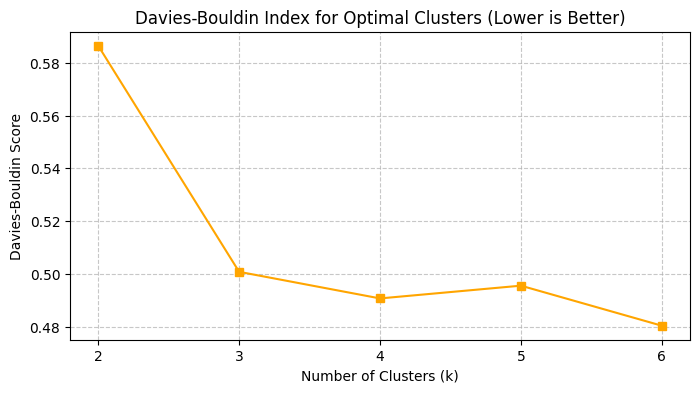

In [10]:
from sklearn.metrics import davies_bouldin_score


def plot_davies_bouldin(elos, k_max, random_state):
    X = np.array(elos).reshape(-1, 1)
    k_values = list(range(2, k_max))
    
    dbscores = []
    for k in k_values:
        k_mean = KMeans(n_clusters=k, random_state=random_state).fit(X)
        score = davies_bouldin_score(X, k_mean.labels_)
        dbscores.append(score)

    print(f"\n{'k (Clusters)':<12} | {'Score'}")
    print("-" * 30)
    for k, val in zip(k_values, dbscores):
        print(f"{k:<12} | {val:,.5f}")

    plt.figure(figsize=(8, 4))
    plt.plot(k_values, dbscores, marker="s", color="orange")
    plt.xticks(k_values)
    plt.title("Davies-Bouldin Index for Optimal Clusters (Lower is Better)")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Davies-Bouldin Score")
    plt.grid(True, linestyle='--', alpha=0.7)
    
    return plt


PATH_PLOT_DB = 'data/DAVIES_BOULDIN_OLD.png'

plt_db = plot_davies_bouldin(ELOS_OLD, K_MAX, RANDOM_STATE)
plt_db.savefig(PATH_PLOT_DB)
plt_db.show()

# 3. CLUSTERING

In [12]:
from sklearn.cluster import KMeans


def add_elo_clusters(df, k, random_state):
    df_clustered = df.copy()
    X = df_clustered[['elo']]
    
    km = KMeans(n_clusters=k, random_state=random_state)
    km.fit(X)
    
    centers = km.cluster_centers_.flatten()
    order = centers.argsort()
    remap = {original_label: new_label + 1 for new_label, original_label in enumerate(order)}
    
    df_clustered['cluster'] = [f"cluster_{remap[label]}" for label in km.labels_]
    
    return df_clustered


K                = 4
RANDOM_STATE     = 42
df_old_clustered = add_elo_clusters(df_old_elos_added, K, RANDOM_STATE)

print(f"\n{'CLUSTER':<12} | {'MIN ELO':<10} | {'MAX ELO':<10} | {'COUNT'}")
print("-" * 50)
summary = df_old_clustered.groupby('cluster')['elo'].agg(['min', 'max', 'count'])
for cluster, row in summary.iterrows():
    print(f"{cluster:<12} | {row['min']:<10} | {row['max']:<10} | {row['count']}")
print("\n")

display(df_old_clustered.tail(3))


CLUSTER      | MIN ELO    | MAX ELO    | COUNT
--------------------------------------------------
cluster_1    | 1210       | 1346       | 13
cluster_2    | 1357       | 1479       | 28
cluster_3    | 1487       | 1592       | 28
cluster_4    | 1610       | 1799       | 23




,order,year,country,study_focus,historical_site_type,historical_site_type_sub,platform,device,technique,technique_sub,software_data,software_modeling,software_render,elo,cluster
89,90,2024,Cyprus,Visualization,Archaeological Site,Underwater,[VR],[HMD],"[Image-Based Techniques, Geospatial Techniques]","[Photogrammetry, Structure from Motion (SfM), Geographic Information System (GIS)]",[Agisoft Metashape],[Blender],[Unreal Engine],1421,cluster_2
90,91,2024,Jordan,Reconstruction,Archaeological Site,LandBased,[VR],[HMD],[Image-Based Techniques],[Photogrammetry],[Agisoft Metashape],[],[Unreal Engine],1638,cluster_4
91,92,2024,Italy,Visualization,Natural Space,Cave,[VR],[HMD],[Image-Based Techniques],[Photogrammetry],[Reality Capture],[],[Unreal Engine],1479,cluster_2


# 4. ONE-HOT

## 4.1. Create Binary Dataset

In [13]:
import re


def format_column_names(original_column_name, dummy_columns):
    prefix = "".join([word[0] for word in original_column_name.split('_') if word])
    
    new_columns = {}
    for val in dummy_columns:
        clean_val = re.sub(r'[^a-z0-9]+', '_', str(val).lower()).strip('_')
        new_columns[val] = f"{prefix}_{clean_val}"
        
    return new_columns


def encode_single_column(df, column_name, is_multi_value):
    if is_multi_value:
        joined_strings = df[column_name].apply(lambda x: '|'.join(x) if isinstance(x, list) else "")
        return joined_strings.str.get_dummies(sep='|')
    else:
        return pd.get_dummies(df[column_name], dtype=int)


def create_df_binary(df, multi_value_columns):
    ignore_columns = ['order', 'year', 'country', 'elo', 'cluster']
    encoded_frames = []
    
    for col in df.columns:
        if col in ignore_columns:
            continue
            
        is_multi_value = col in multi_value_columns
        df_encoded     = encode_single_column(df, col, is_multi_value)
        new_names      = format_column_names(col, df_encoded.columns)
        df_encoded     = df_encoded.rename(columns=new_names)
        
        encoded_frames.append(df_encoded)

    return pd.concat(encoded_frames, axis=1)


df_old_binary = create_df_binary(df_old_clustered, multi_value_columns)
print(df_old_binary.shape[1])
display(df_old_binary.head(3))

124


,sf_reconstruction,sf_restoration,sf_visualization,hst_archaeological_site,hst_artistic_feature,hst_building,hst_natural_space,hsts_architecturalasset,hsts_artifact,hsts_cave,hsts_fortification,hsts_landbased,hsts_religious,hsts_underwater,hsts_urbanspace,p_ar,p_mr,p_vr,p_xr,d_hmd,d_immersive_display,d_mobile,d_pc,t_3d_scanning,t_data_processing,t_geospatial_techniques,t_image_based_techniques,t_modeling_reconstruction,ts_3d_modeling,ts_3d_texturing,ts_archaeological_interpretation,ts_bim,ts_beacon_localization,ts_digital_elevation_models_dem,ts_geographic_information_system_gis,ts_global_navigation_satellite_system_gnss,ts_hbim,ts_hdr_imaging,ts_image_based_modeling_ibm,ts_laser_scanning,ts_multi_view_stereo_mvs,ts_photogrammetry,ts_rgb_d_imaging,ts_range_based_modeling_rbm,ts_real_time_volumetric_capture,ts_semantic_data_extraction,ts_spherical_imaging,ts_stratigraphic_mapping,ts_structure_from_motion_sfm,ts_texture_mapping,ts_uav_aerial_imaging,ts_virtual_anastylosis,ts_visual_inertial_slam,sd_3df_zephyr,sd_affinity,sd_agisoft_metashape,sd_arcgis,sd_arcmap,sd_australis_photometric,sd_autodesk_meshmixer,sd_autodesk_mudbox,sd_autodesk_recap,sd_catia,sd_cloudcompare,sd_contextcapture,sd_dstretch,sd_dynamo,sd_faro_scene,sd_focus_scene,sd_graphos,sd_leica_cyclone,sd_matlab,sd_mesh_buildup_wizard,sd_mongodb,sd_mysql,sd_pix4d_capture,sd_ptgui,sd_polycam,sd_processing,sd_qgis,sd_reality_capture,sd_riegl_riscan,sd_trimble_business_center,sd_trimble_realworks,sd_world_creator_2,sm_3dreshaper,sm_archicad,sm_autodesk_3ds_max,sm_autodesk_autocad,sm_autodesk_maya,sm_autodesk_remake,sm_autodesk_revit,sm_blender,sm_fuente_nueva,sm_geomagic,sm_maxon_cinema4d,sm_meshlab,sm_meshmixer,sm_ramsete,sm_rhinoceros,sm_simlab,sm_sketchup,sm_zbrush,sr_arkit,sr_augment,sr_easyar,sr_enscape,sr_fb360_encoder,sr_gimp,sr_kolor_panotour,sr_lumion,sr_maxwhere,sr_middlevr,sr_pano2vr,sr_renderman,sr_shapespark,sr_sketchfab,sr_three_js,sr_twinmotion,sr_unity,sr_unreal_engine,sr_v_ray,sr_verge3d,sr_vuforia
0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 4.2. Find MIN_FREQ

Calculated MIN_FREQ: 17

BIN RANGE            | FEATURE COUNT
-----------------------------------
1.00 - 3.73          | 75
3.73 - 6.47          | 15
6.47 - 9.20          | 6
9.20 - 11.93         | 4
11.93 - 14.67        | 2
14.67 - 17.40        | 1
17.40 - 20.13        | 3
20.13 - 22.87        | 0
22.87 - 25.60        | 0
25.60 - 28.33        | 2
28.33 - 31.07        | 0
31.07 - 33.80        | 4
33.80 - 36.53        | 0
36.53 - 39.27        | 0
39.27 - 42.00        | 0
42.00 - 44.73        | 2
44.73 - 47.47        | 4
47.47 - 50.20        | 1
50.20 - 52.93        | 0
52.93 - 55.67        | 0
55.67 - 58.40        | 1
58.40 - 61.13        | 0
61.13 - 63.87        | 0
63.87 - 66.60        | 0
66.60 - 69.33        | 0
69.33 - 72.07        | 0
72.07 - 74.80        | 0
74.80 - 77.53        | 2
77.53 - 80.27        | 1
80.27 - 83.00        | 1




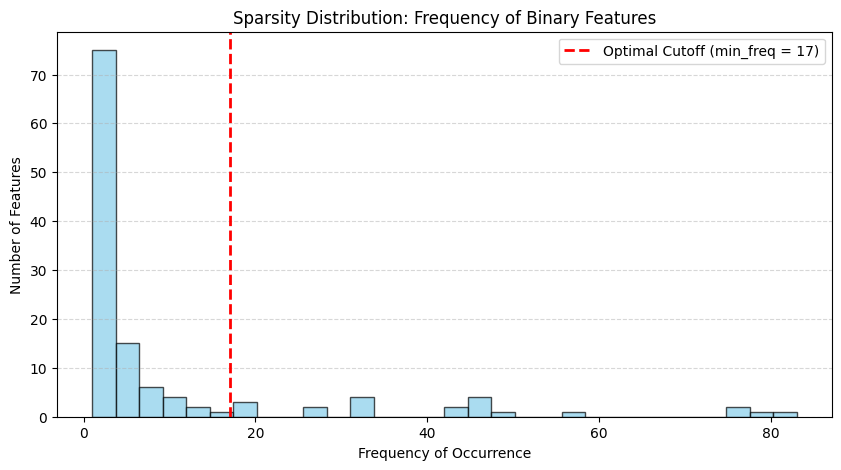

In [14]:
def calculate_optimal_min_freq(frequencies, bins=30):
    counts, bin_edges = np.histogram(frequencies, bins=bins)
    
    trough_idx = 0
    for i in range(1, len(counts) - 1):
        if counts[i] <= counts[i-1] and counts[i] < counts[i+1]:
            trough_idx = i
            break
            
    return int(round(bin_edges[trough_idx + 1]))


def plot_sparsity_distribution(frequencies, threshold, bins=30):
    plt.figure(figsize=(10, 5))
    n, bin_edges, _ = plt.hist(frequencies, bins=bins, color='skyblue', edgecolor='black', alpha=0.7)
    
    plt.axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Optimal Cutoff (min_freq = {threshold})')
    plt.title("Sparsity Distribution: Frequency of Binary Features")
    plt.xlabel("Frequency of Occurrence")
    plt.ylabel("Number of Features")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)

    print(f"\n{'BIN RANGE':<20} | {'FEATURE COUNT'}")
    print("-" * 35)
    for i in range(len(n)):
        bin_label = f"{bin_edges[i]:.2f} - {bin_edges[i+1]:.2f}"
        print(f"{bin_label:<20} | {int(n[i])}")
    print("\n")
    
    return plt


feature_frequencies = df_old_binary.sum()

MIN_FREQ = calculate_optimal_min_freq(feature_frequencies)
print(f"Calculated MIN_FREQ: {MIN_FREQ}")

PATH_PLOT_SPARSITY = 'data/SPARSITY_OLD.png'
plt_sparsity = plot_sparsity_distribution(feature_frequencies, MIN_FREQ)
plt_sparsity.savefig(PATH_PLOT_SPARSITY)
plt_sparsity.show()

## 4.3. Filter Rare Binaries

In [17]:
def filter_rare_features(df_binary, min_freq):
    frequencies       = df_binary.sum()
    valid_columns     = frequencies[frequencies >= min_freq].index
    df_rares_filtered = df_binary[valid_columns].copy()
    
    return df_rares_filtered


df_old_rares_filtered = filter_rare_features(df_old_binary, MIN_FREQ)
display(df_old_rares_filtered.tail(3))


print(f"Total binary features    : {df_old_binary.shape[1]}")
print(f"Dropped binary features  : {df_old_binary.shape[1] - df_old_rares_filtered.shape[1]}")
print(f"Remaining binary features: {df_old_rares_filtered.shape[1]}")

,sf_reconstruction,sf_visualization,hst_archaeological_site,hst_building,hsts_landbased,hsts_religious,p_ar,p_vr,d_hmd,d_mobile,d_pc,t_3d_scanning,t_image_based_techniques,t_modeling_reconstruction,ts_3d_modeling,ts_laser_scanning,ts_photogrammetry,sd_agisoft_metashape,sm_blender,sr_unity,sr_unreal_engine
89,0,1,1,0,0,0,0,1,1,0,0,0,1,0,0,0,1,1,1,0,1
90,1,0,1,0,1,0,0,1,1,0,0,0,1,0,0,0,1,1,0,0,1
91,0,1,0,0,0,0,0,1,1,0,0,0,1,0,0,0,1,0,0,0,1


Total binary features    : 124
Dropped binary features  : 103
Remaining binary features: 21


## 4.4. Summary

In [18]:
def print_binary_summary(df_binary, w_name=45, w_count=10, w_pct=10): 
    header = f"{'FEATURE':<{w_name}} | {'COUNT':<{w_count}} | {'PERCENT':<{w_pct}}"
    print(header)
    print("─" * len(header))

    total_rows = len(df_binary)
    frequencies = df_binary.sum().sort_values(ascending=False)
    
    for feature, count in frequencies.items():
        percent_str = f"{round((count / total_rows) * 100, 1)}%"
        print(f"{str(feature):<{w_name}} | {str(count):<{w_count}} | {percent_str:<{w_pct}}")


# print_dataset_summary(df_rares_filtered, [])
print_binary_summary(df_old_rares_filtered)

FEATURE                                       | COUNT      | PERCENT   
───────────────────────────────────────────────────────────────────────
t_image_based_techniques                      | 83         | 90.2%     
ts_photogrammetry                             | 79         | 85.9%     
p_vr                                          | 76         | 82.6%     
d_hmd                                         | 76         | 82.6%     
sf_visualization                              | 58         | 63.0%     
sd_agisoft_metashape                          | 50         | 54.3%     
sr_unity                                      | 47         | 51.1%     
hst_archaeological_site                       | 47         | 51.1%     
t_3d_scanning                                 | 46         | 50.0%     
t_modeling_reconstruction                     | 45         | 48.9%     
ts_laser_scanning                             | 44         | 47.8%     
hsts_landbased                                | 44         | 47.

# 5. TRAIN/TEST

In [19]:
from sklearn.model_selection import train_test_split


def prepare_train_test_split(X_features, original_df, test_size=0.20, random_state=42):
    y = original_df['cluster']
    X = X_features.copy()
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, 
        test_size=test_size, 
        random_state=random_state, 
        stratify=y # 4 clusters are even!
    )
    
    print(f"{'METRIC':<10} | {'TOTAL':<10} | {'TRAIN':<10} | {'TEST':<10}")
    print("-" * 50)
    print(f"{'Samples':<10} | {len(X):<10} | {len(X_train):<10} | {len(X_test):<10}")
    print(f"{'Features':<10} | {X.shape[1]:<10} | {X_train.shape[1]:<10} | {X_test.shape[1]:<10}")
    print("\n")
    
    print(f"{'CLUSTER':<10} | {'TOTAL':<10} | {'TRAIN':<10} | {'TEST':<10}")
    print("-" * 50)
    train_counts = y_train.value_counts().sort_index()
    test_counts  = y_test.value_counts().sort_index()
    for cluster in train_counts.index:
        train_val = train_counts.get(cluster, 0)
        test_val  = test_counts.get(cluster, 0)
        total_val = train_val + test_val
        print(f"{cluster:<10} | {total_val:<10} | {train_val:<10} | {test_val:<10}")
        
    return X_train, X_test, y_train, y_test


X_train, X_test, y_train, y_test = prepare_train_test_split(df_old_rares_filtered, df_old_clustered)

METRIC     | TOTAL      | TRAIN      | TEST      
--------------------------------------------------
Samples    | 92         | 73         | 19        
Features   | 21         | 21         | 21        


CLUSTER    | TOTAL      | TRAIN      | TEST      
--------------------------------------------------
cluster_1  | 13         | 11         | 2         
cluster_2  | 28         | 22         | 6         
cluster_3  | 28         | 22         | 6         
cluster_4  | 23         | 18         | 5         


# 6. f_score & p_value

In [20]:
import pandas as pd
from sklearn.feature_selection import f_classif


def analyze_feature_significance(X_train, y_train):
    f_scores, p_values = f_classif(X_train, y_train)
      
    df_stats = pd.DataFrame({
        'feature': X_train.columns,
        'count'  : X_train.sum().values,
        'f_score': f_scores,
        'p_value': p_values
    })
    
    df_stats['significant (p<0.05)'] = df_stats['p_value'] < 0.05
    df_stats['f_score'] = df_stats['f_score'].apply(lambda x: f"{x:.2f}")
    df_stats['p_value'] = df_stats['p_value'].apply(lambda x: f"{x:.4f}")
    df_stats = df_stats.sort_values(by='p_value', ascending=True).reset_index(drop=True)
    
    return df_stats


print(f"Feature Significance Analysis (Training Data N={len(X_train)}):")
print('-'*80)
df_old_significance = analyze_feature_significance(X_train, y_train)
display(df_old_significance)

Feature Significance Analysis (Training Data N=73):
--------------------------------------------------------------------------------


,feature,count,f_score,p_value,significant (p<0.05)
0,p_ar,22,2.83,0.0448,True
1,sr_unity,38,2.26,0.0894,False
2,sf_reconstruction,20,1.24,0.3019,False
3,t_3d_scanning,36,1.23,0.3044,False
4,ts_laser_scanning,34,1.06,0.3715,False
5,t_image_based_techniques,64,0.99,0.4040,False
6,d_hmd,59,0.84,0.4740,False
7,d_mobile,26,0.79,0.5019,False
8,sr_unreal_engine,13,0.67,0.5752,False
9,hsts_religious,13,0.56,0.6407,False


# 7. MACHINE LEARNING

## 7.1. 80/20 Test

In [21]:
from sklearn.naive_bayes    import GaussianNB
from sklearn.linear_model   import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.tree           import DecisionTreeClassifier
from sklearn.ensemble       import RandomForestClassifier
from sklearn.svm            import SVC
from sklearn.neighbors      import KNeighborsClassifier

from sklearn.metrics        import accuracy_score
import time,warnings


MODELS = [
    ('Naive Bayes (Gaussian)'                  , GaussianNB()),
    ('Logistic Regression (ridge)'             , LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)),
    ('Deep Neural Network (two hidden layers)' , MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)),
    ('Decision Tree (CART)'                    , DecisionTreeClassifier(random_state=42)),
    ('Random Forest (100 trees)'               , RandomForestClassifier(n_estimators=100, random_state=42)),
    ('Support Vector Machine (RBF Kernel)'     , SVC(kernel='rbf', random_state=42)),
    ('k-Nearest Neighbors'                     , KNeighborsClassifier()),
]


def train_models(models_list, X_train, y_train, X_test, y_test):
    trained_models = {}
    
    for name, model in models_list:
        start_time = time.perf_counter()
        
        model.fit(X_train, y_train)
        y_predictions = model.predict(X_test)

        end_time = time.perf_counter()
        run_time = end_time - start_time
        accuracy = accuracy_score(y_test, y_predictions)
        
        trained_models[name] = {
            'model'      : model,
            'predictions': y_predictions,
            'accuracy'   : accuracy,
            'run_time'   : run_time
        }

    return trained_models


def print_model_leaderboard(trained_models):
    print(f"\n{'MACHINE LEARNING MODELS':<40} | {'ACCURACY':<10} | {'RUN TIME':<10}")
    print("-" * 80)
    
    for name, data in trained_models.items():
        accuracy = data['accuracy']
        run_time = data['run_time']
        print(f"{name:<40} | {accuracy * 100:>7.2f}%   | {run_time:>7.4f}s")


results_dict = train_models(MODELS, X_train, y_train, X_test, y_test)
print_model_leaderboard(results_dict)


MACHINE LEARNING MODELS                  | ACCURACY   | RUN TIME  
--------------------------------------------------------------------------------
Naive Bayes (Gaussian)                   |   42.11%   |  0.0029s
Logistic Regression (ridge)              |   21.05%   |  0.0139s
Deep Neural Network (two hidden layers)  |   31.58%   |  0.1506s
Decision Tree (CART)                     |   36.84%   |  0.0018s
Random Forest (100 trees)                |   47.37%   |  0.0966s
Support Vector Machine (RBF Kernel)      |   47.37%   |  0.0024s
k-Nearest Neighbors                      |   31.58%   |  0.0023s


## 7.2. Cross Validate

In [23]:
from sklearn.model_selection import cross_val_score, StratifiedKFold


def cross_validate_models(models_list, X, y, splits=5):
    cv_results = {}
    skf = StratifiedKFold(n_splits=splits, shuffle=True, random_state=42)
    
    for name, model in models_list:
        start_time    = time.perf_counter()
        scores        = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
        end_time      = time.perf_counter()
        
        cv_results[name] = {
            'accuracy': np.mean(scores),
            'scores'  : scores,
            'run_time': end_time - start_time
        }
        
    return cv_results


def print_cv_leaderboard(cv_results):
    print(f"\n{'MACHINE LEARNING MODELS':<40} | {'CV ACCURACY':<19} | {'RUN TIME':<10}")
    print("-" * 80)
       
    for name, data in cv_results.items():
        acc = data['accuracy']
        rt  = data['run_time']
        std = np.std(data['scores'])
        print(f"{name:<40} | {acc * 100:>6.2f}% (+/- {std * 100:>4.1f}%) | {rt:>7.4f}s")


X_full          = df_old_rares_filtered.copy()
y_full          = df_old_clustered['cluster']
cv_results_dict = cross_validate_models(MODELS, X_full, y_full)
print_cv_leaderboard(cv_results_dict)


MACHINE LEARNING MODELS                  | CV ACCURACY         | RUN TIME  
--------------------------------------------------------------------------------
Naive Bayes (Gaussian)                   |  15.09% (+/-  6.9%) |  0.0175s
Logistic Regression (ridge)              |  20.53% (+/-  8.9%) |  0.0626s
Deep Neural Network (two hidden layers)  |  25.03% (+/- 15.1%) |  0.6685s
Decision Tree (CART)                     |  20.53% (+/-  8.9%) |  0.0134s
Random Forest (100 trees)                |  30.41% (+/- 11.1%) |  0.4953s
Support Vector Machine (RBF Kernel)      |  31.64% (+/- 12.1%) |  0.0236s
k-Nearest Neighbors                      |  27.37% (+/- 11.9%) |  0.0167s
